In [1]:
# Used to test the existing model with "common sense problems" 
import sys
import os

sys.path.append(os.path.abspath(".."))
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import chess

from tqdm import tqdm
from torch.utils.data import DataLoader

from model import NNUE

from dataset import extract_halfkp
from engine.eval import model_evaluate_board

import random
import matplotlib.pyplot as plt

In [2]:
def undo_tanh(score, clip=0.9999):
    """Invert the tanh normalization from transform_row: tanh(cp / 400) -> cp."""
    return np.arctanh(np.clip(score, -clip, clip)) * 400.0

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(device)

mps


In [4]:
model = NNUE().to(device)
checkpoint = torch.load("nnue_checkpoints/chess_model_step_100000.pt", map_location=torch.device('cpu')) # cuda trained needs this key
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [5]:
# test 1, give three fen positions, see if engine can evaluate reasonably
# NOTE: eval is always from stm perspective.
def test1_common_sense(model, device, undo=False):
    def fmt(score):
        return f"{undo_tanh(score):.1f} cp" if undo else f"{score:.6f}"

    fen1 = "r1bqkb1r/pppp1ppp/2n2n2/4p1N1/2B1P3/8/PPPP1PPP/RNBQK2R b KQkq - 0 1" # normal opening position, (expected: small positive or near 0)
    print("fen1 (normal opening)      :", fmt(model_evaluate_board(model, chess.Board(fen1), device)))

    fen2 = "r1bNk2r/pppp2pp/2n4n/2b1p3/2B1P3/8/PPPP1PPP/RNBQK2R w KQkq - 0 1" # white has won a queen in the opening should be white winning (expected: high number)
    print("fen2 (white up queen)      :", fmt(model_evaluate_board(model, chess.Board(fen2), device)))

    fen3 = "rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq e3 0 1" # starting position white up a queen. should be white winning (expected: high number)
    print("fen3 (start + white queen) :", fmt(model_evaluate_board(model, chess.Board(fen3), device)))

    fen4 = "r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 0 4" # mate in one for white and white to move (expected: high number)
    print("fen4 (mate in one)         :", fmt(model_evaluate_board(model, chess.Board(fen4), device)))

    fen5 = "r1bqkbn1/pppppppr/n6p/2QPP3/2P5/2N2NB1/PP2BPPP/3R1RK1 b q - 0 1" # (black tm) white is well developed but the queen is hanging (expected: medium high)
    print("fen5 (white Q hanging)     :", fmt(model_evaluate_board(model, chess.Board(fen5), device)))

#test1_common_sense(model, device)
test1_common_sense(model, device, True)

fen1 (normal opening)      : 64.5 cp
fen2 (white up queen)      : 755.4 cp
fen3 (start + white queen) : 788.6 cp
fen4 (mate in one)         : -24.5 cp
fen5 (white Q hanging)     : -397.7 cp


In [6]:
# test2: can the model value pieces; add a pawn, add a knight, add a bishop, add a rook, add a queen and should be < <= < <
def test_piece_values(model, device, undo=False):
    def fmt(score):
        return f"{undo_tanh(score):.1f} cp" if undo else f"{score:.6f}"

    base_fen = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"

    # Add pieces one at a time for white
    pawn_board = chess.Board(base_fen)
    pawn_board.set_piece_at(chess.E4, chess.Piece(chess.PAWN, chess.WHITE))

    knight_board = chess.Board(base_fen)
    knight_board.set_piece_at(chess.E4, chess.Piece(chess.KNIGHT, chess.WHITE))

    bishop_board = chess.Board(base_fen)
    bishop_board.set_piece_at(chess.E4, chess.Piece(chess.BISHOP, chess.WHITE))

    rook_board = chess.Board(base_fen)
    rook_board.set_piece_at(chess.E4, chess.Piece(chess.ROOK, chess.WHITE))

    queen_board = chess.Board(base_fen)
    queen_board.set_piece_at(chess.E4, chess.Piece(chess.QUEEN, chess.WHITE))

    print("Pawn  :", fmt(model_evaluate_board(model, pawn_board, device)))
    print("Knight:", fmt(model_evaluate_board(model, knight_board, device)))
    print("Bishop:", fmt(model_evaluate_board(model, bishop_board, device)))
    print("Rook  :", fmt(model_evaluate_board(model, rook_board, device)))
    print("Queen :", fmt(model_evaluate_board(model, queen_board, device)))

test_piece_values(model, device, True)

Pawn  : 88.8 cp
Knight: 435.3 cp
Bishop: 570.7 cp
Rook  : 624.9 cp
Queen : 803.9 cp


In [7]:
# test3: sanity check if symmetry is correct
def test_color_symmetry(model, device, undo=False):
    def fmt(score):
        return f"{undo_tanh(score):.1f} cp" if undo else f"{score:.6f}"

    fen = "rnbqk3/ppNppp1p/1r3b1p/3P1N2/4PP2/P6P/2PQ2P1/1RB1KB1R b Kq - 0 1"
    
    board = chess.Board(fen)
    flipped = board.mirror()

    print(board, board.turn)
    print()
    print(flipped, flipped.turn)

    val1 = model_evaluate_board(model, board, device)
    val2 = model_evaluate_board(model, flipped, device)

    print("Original:", fmt(val1))
    print("Mirrored:", fmt(val2))

test_color_symmetry(model, device)

r n b q k . . .
p p N p p p . p
. r . . . b . p
. . . P . N . .
. . . . P P . .
P . . . . . . P
. . P Q . . P .
. R B . K B . R False

. r b . k b . r
. . p q . . p .
p . . . . . . p
. . . . p p . .
. . . p . n . .
. R . . . B . P
P P n P P P . P
R N B Q K . . . True
Original: -0.912984
Mirrored: -0.912984


Evaluating random positions: 100%|██████████| 5000/5000 [00:15<00:00, 321.19it/s]


n            : 4954
mean         : 51.7592 centipawns
std          : 350.7050 centipawns
min          : -772.6785 centipawns
max          : 864.5020 centipawns
median       : 26.8549 centipawns
p25 / p75    : -169.7748 / 238.0618 centipawns
p5  / p95    : -480.5577 / 776.2582 centipawns


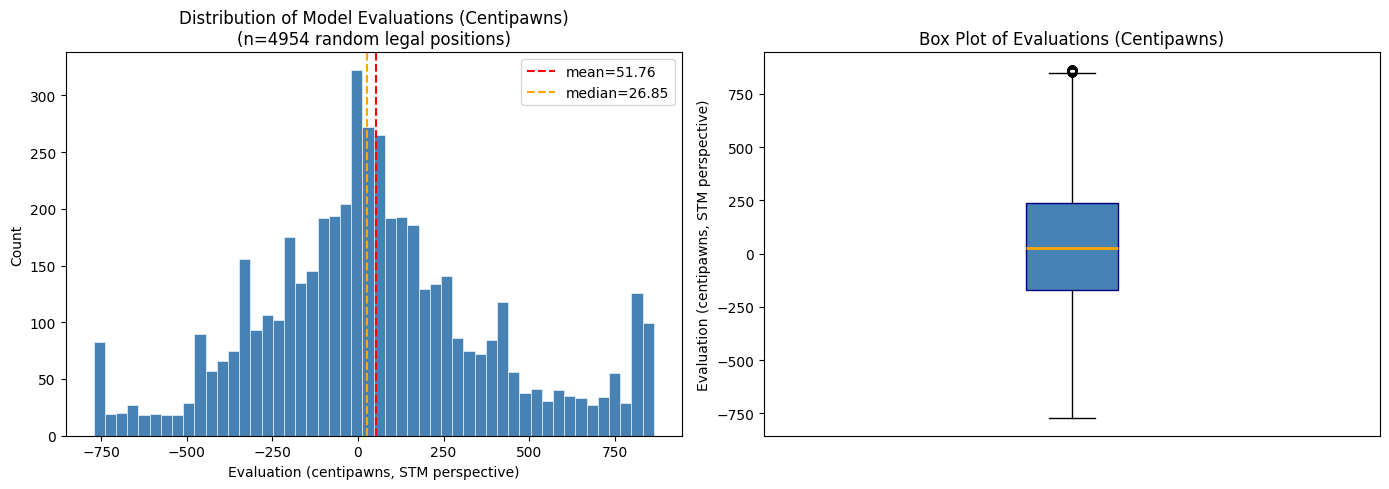

In [8]:
# test4: evaluate distribution of model scores on random legal positions
def generate_random_position(min_moves=10, max_moves=80):
    board = chess.Board()
    n_moves = random.randint(min_moves, max_moves)
    for _ in range(n_moves):
        if board.is_game_over():
            break
        move = random.choice(list(board.legal_moves))
        board.push(move)
    return board if not board.is_game_over() else None

def test4_random_eval_distribution(model, device, n_positions=500, seed=42, undo=False):
    random.seed(seed)
    scores = []

    for _ in tqdm(range(n_positions), desc="Evaluating random positions"):
        board = generate_random_position()
        if board is None:
            continue
        scores.append(model_evaluate_board(model, board, device))

    scores = np.array(scores)
    display = undo_tanh(scores) if undo else scores
    unit = "centipawns" if undo else "tanh score"

    # Stats
    print(f"n            : {len(display)}")
    print(f"mean         : {display.mean():.4f} {unit}")
    print(f"std          : {display.std():.4f} {unit}")
    print(f"min          : {display.min():.4f} {unit}")
    print(f"max          : {display.max():.4f} {unit}")
    print(f"median       : {np.median(display):.4f} {unit}")
    print(f"p25 / p75    : {np.percentile(display, 25):.4f} / {np.percentile(display, 75):.4f} {unit}")
    print(f"p5  / p95    : {np.percentile(display, 5):.4f} / {np.percentile(display, 95):.4f} {unit}")

    xlabel = f"Evaluation ({unit}, STM perspective)"
    title_unit = "Centipawns" if undo else "Tanh Score [-1, 1]"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(display, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
    axes[0].axvline(display.mean(), color="red", linestyle="--", label=f"mean={display.mean():.2f}")
    axes[0].axvline(np.median(display), color="orange", linestyle="--", label=f"median={np.median(display):.2f}")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Distribution of Model Evaluations ({title_unit})\n(n={len(display)} random legal positions)")
    axes[0].legend()

    axes[1].boxplot(display, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", color="navy"),
                    medianprops=dict(color="orange", linewidth=2))
    axes[1].set_ylabel(xlabel)
    axes[1].set_title(f"Box Plot of Evaluations ({title_unit})")
    axes[1].set_xticks([])

    plt.tight_layout()
    plt.show()

    return scores

scores = test4_random_eval_distribution(model, device, n_positions=5000, undo=True)

In [9]:
# test5: verify the accumulator gives the same evaluation as full model_evaluate_board
# across every move type: normal, capture, en passant, castling, promotion, king move, and undo.
#
# Gold reference : model_evaluate_board (full feature extraction + forward pass each call)
# Accumulator    : NNUEAccumulator incremental updates + model.evaluate_acc (output layer only)

from engine.accumulator import NNUEAccumulator

def test5_accumulator(model, device, tol=1e-4):
    acc = NNUEAccumulator(model)

    def gold(board):
        return model_evaluate_board(model, board, device)

    def via_acc(board):
        dev = acc.model_device
        if board.turn == chess.WHITE:
            stm, nstm = acc.white.to(dev), acc.black.to(dev)
        else:
            stm, nstm = acc.black.to(dev), acc.white.to(dev)
        return model.evaluate_acc(stm, nstm)

    def check(label, board):
        g, a = gold(board), via_acc(board)
        diff = abs(g - a)
        ok = diff < tol
        print(f"  [{'PASS' if ok else 'FAIL'}] {label:<32s}  gold={g:+.6f}  acc={a:+.6f}  diff={diff:.2e}")
        return ok

    results = []

    # ── 1. Opening moves + kingside castling ─────────────────────────────────
    print("1. Opening moves + O-O castling")
    board = chess.Board()
    acc.init_from_board(board)
    seq = ['e2e4', 'e7e5', 'g1f3', 'b8c6', 'f1c4', 'g8f6', 'e1g1']
    for uci in seq:
        acc.push(board, chess.Move.from_uci(uci))
        results.append(check(f"push {uci}", board))
    for uci in reversed(seq):
        acc.pop(board)
        results.append(check(f"undo {uci}", board))

    # ── 2. Capture sequence ──────────────────────────────────────────────────
    print("\n2. Captures")
    board = chess.Board()
    acc.init_from_board(board)
    seq = ['e2e4', 'd7d5', 'e4d5', 'c7c6', 'd5c6', 'b8a6']
    for uci in seq:
        acc.push(board, chess.Move.from_uci(uci))
        results.append(check(f"push {uci}", board))
    for uci in reversed(seq):
        acc.pop(board)
        results.append(check(f"undo {uci}", board))

    # ── 3. En passant ────────────────────────────────────────────────────────
    print("\n3. En passant")
    board = chess.Board('rnbqkbnr/ppp1pppp/8/3pP3/8/8/PPPP1PPP/RNBQKBNR w KQkq d6 0 3')
    acc.init_from_board(board)
    acc.push(board, chess.Move.from_uci('e5d6'))
    results.append(check("push e5d6 (ep capture)", board))
    acc.pop(board)
    results.append(check("undo e5d6", board))

    # ── 4. Promotion (all four piece types) ──────────────────────────────────
    print("\n4. Promotion")
    for promo in ['a7a8q', 'a7a8r', 'a7a8b', 'a7a8n']:
        board2 = chess.Board('8/P7/8/8/8/8/8/k6K w - - 0 1')
        acc.init_from_board(board2)
        acc.push(board2, chess.Move.from_uci(promo))
        results.append(check(f"push {promo}", board2))
        acc.pop(board2)
        results.append(check(f"undo {promo}", board2))

    # ── 5. King moves (triggers full perspective refresh) ────────────────────
    # Use a position where both kings have unobstructed squares to move to.
    print("\n5. King moves")
    board = chess.Board('r3k2r/ppp2ppp/2n2n2/4p3/2B1P3/5N2/PPP2PPP/R3K2R w KQkq - 0 10')
    acc.init_from_board(board)
    seq = ['e1f1', 'e8d8', 'f1e2', 'd8c8']
    for uci in seq:
        acc.push(board, chess.Move.from_uci(uci))
        results.append(check(f"push {uci} (king)", board))
    for uci in reversed(seq):
        acc.pop(board)
        results.append(check(f"undo {uci} (king)", board))

    # ── 6. Queenside castling ────────────────────────────────────────────────
    print("\n6. Queenside castling (O-O-O)")
    board = chess.Board('r3kbnr/pppqpppp/2np4/4b3/4P3/2NP1N2/PPPB1PPP/R3KB1R w KQkq - 4 7')
    acc.init_from_board(board)
    acc.push(board, chess.Move.from_uci('e1c1'))
    results.append(check("push e1c1 (O-O-O)", board))
    acc.pop(board)
    results.append(check("undo e1c1", board))

    # ── Summary ──────────────────────────────────────────────────────────────
    n_pass = sum(results)
    n_total = len(results)
    print(f"\n{'='*60}")
    print(f"RESULT: {n_pass}/{n_total} checks passed", "✓" if n_pass == n_total else "✗")
    return n_pass == n_total

test5_accumulator(model, device)


1. Opening moves + O-O castling
  [PASS] push e2e4                         gold=-0.051488  acc=-0.051488  diff=0.00e+00
  [PASS] push e7e5                         gold=+0.123412  acc=+0.123412  diff=6.71e-08
  [PASS] push g1f3                         gold=-0.001763  acc=-0.001763  diff=0.00e+00
  [PASS] push b8c6                         gold=+0.169171  acc=+0.169171  diff=5.96e-08
  [PASS] push f1c4                         gold=+0.000234  acc=+0.000234  diff=0.00e+00
  [PASS] push g8f6                         gold=+0.355196  acc=+0.355197  diff=5.96e-08
  [PASS] push e1g1                         gold=-0.051221  acc=-0.051221  diff=7.45e-09
  [PASS] undo e1g1                         gold=+0.355196  acc=+0.355197  diff=5.96e-08
  [PASS] undo g8f6                         gold=+0.000234  acc=+0.000234  diff=0.00e+00
  [PASS] undo f1c4                         gold=+0.169171  acc=+0.169171  diff=5.96e-08
  [PASS] undo b8c6                         gold=-0.001763  acc=-0.001763  diff=0.00e+00


True